# CS156: Pipeline - Second Draft

**Can You Diagnose Autism From Brain Noise?**

There’s a persistent idea in computational neuroscience that you can look at a brain scan and read *something* meaningful: a diagnosis, a trait, or a difference in how someone thinks. It’s a compelling idea. It’s also, at best, an approximation.

This project starts from a deliberately uncomfortable question:

> If you take a noisy, indirect measurement of brain activity and reduce it to correlations between ~200 regions, is there actually enough signal left to distinguish individuals with Autism Spectrum Disorder (ASD) from controls?

The data used here are resting-state fMRI time series, summarized as functional connectivity matrices. In practice, this means:
- we are not observing neural activity directly  
- we are not measuring interactions between regions  
- we are measuring statistical co-variation under a long chain of preprocessing assumptions  

So the object we feed into our models is already several steps removed from anything we might confidently call “brain function.”

Given that, the goal of this project is not to build a diagnostic tool, but rather to test how different modeling assumptions behave when applied to this representation.

Each subject is represented as a connectivity matrix derived from ROI time series (`rois_cc200`). From there, we ask a simple but pointed question:

> Does treating the brain as a graph actually help, or are we just adding structure to noise?

To answer this, we compare four approaches:

* Logistic Regression on flattened connectivity features  
* A multilayer perceptron (MLP) on the same representation  
* A graph convolutional network (GCN) that assumes connectivity structure matters  
* A graph attention network (GAT) that learns which connections to emphasize  

All models operate on the same underlying data, allowing differences in performance to reflect model assumptions rather than differences in input.

If graph-based models outperform simpler baselines, that suggests there is meaningful relational structure in the data. If they do not, it raises a more uncomfortable possibility: that increasing model sophistication does not recover signal that may not be there to begin with.

The notebook proceeds as follows:

1. Load and verify the curated dataset  
2. Construct functional connectivity matrices  
3. Prepare inputs for each modeling approach  
4. Train and evaluate models under consistent conditions  
5. Compare results and analyze differences  

The aim is not to settle whether functional connectivity can diagnose ASD, but to probe how far this representation can be pushed—and where it breaks down.

# Data

## Data Source

## Preprocessing Done on Original Data

# Loading the Data and Feature Engineering

## Matrix Representation

## Graph Representation

In [ ]:
# Load time-series data and compute Pearson correlation matrices (functional connectivity)
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

base_dir = Path("data") / "abide_fmri"
ts_dir = base_dir / "timeseries"
fc_dir = base_dir / "connectivity_matrices"

print("[INIT] Ensuring output directory exists...")
fc_dir.mkdir(parents=True, exist_ok=True)

subjects_path = base_dir / "subjects_clean.csv"

# Step 1: Load subject list from CSV or filesystem
print("[STEP 1] Getting subject list...")

if subjects_path.exists():
    print("  -> Reading CSV")
    subjects_df = pd.read_csv(subjects_path)
    print("  -> CSV loaded")

    file_ids = subjects_df["FILE_ID"].dropna().astype(str).drop_duplicates().tolist()
    print("  -> Extracted FILE_IDs")
else:
    print("  -> No CSV found, scanning timeseries folder")
    file_ids = sorted(p.stem for p in ts_dir.glob("*.1D"))

print(f"[STEP 1 DONE] {len(file_ids)} subjects")

valid_ids = []
failed_ids = []
skipped_ids = []
roi_count = None

# Step 2: Process each subject's time series and compute functional connectivity
print("[STEP 2] Starting processing loop...")

for i, fid in enumerate(tqdm(file_ids, desc="Processing")):
    ts_path = ts_dir / f"{fid}.1D"
    fc_path = fc_dir / f"{fid}.npy"

    # Skip subjects whose connectivity matrices already exist
    if fc_path.exists():
        skipped_ids.append(fid)
        valid_ids.append(fid)
        continue

    if not ts_path.exists():
        print(f"[WARN] Missing file: {fid}")
        failed_ids.append(fid)
        continue

    try:
        ts = np.loadtxt(ts_path)

        if ts.ndim != 2:
            print(f"[WARN] Bad shape (ndim) for {fid}: {ts.ndim}")
            failed_ids.append(fid)
            continue

        # Ensure time series is (time_points, 200_ROIs) format
        if ts.shape[1] == 200:
            pass
        elif ts.shape[0] == 200:
            ts = ts.T
            print(f"[INFO] Transposed: {fid}")
        else:
            print(f"[WARN] Unexpected shape for {fid}: {ts.shape}")
            failed_ids.append(fid)
            continue

        # Compute Pearson correlation between ROI time series
        corr = np.corrcoef(ts, rowvar=False)
        corr = np.nan_to_num(corr).astype(np.float32)  # Replace NaN with 0, convert to float32
        np.fill_diagonal(corr, 0)  # Remove self-loops

        if roi_count is None:
            roi_count = corr.shape[0]
            print(f"[INFO] ROI count set to {roi_count}")

        if corr.shape != (roi_count, roi_count):
            print(f"[WARN] Shape mismatch for {fid}: {corr.shape}")
            failed_ids.append(fid)
            continue

        np.save(fc_path, corr)
        valid_ids.append(fid)

    except Exception as e:
        print(f"[ERROR] Failed {fid}: {e}")
        failed_ids.append(fid)

print("[STEP 2 DONE] Processing finished")

# Step 3: Create index file linking FILE_IDs to their connectivity matrices and labels
print("[STEP 3] Building index...")

index_df = pd.DataFrame({"FILE_ID": valid_ids})

if subjects_path.exists():
    subjects_clean = subjects_df[subjects_df["FILE_ID"].isin(valid_ids)].copy()
    subjects_clean.to_csv(base_dir / "subjects_with_fc.csv", index=False)

    index_df = index_df.merge(
        subjects_clean[["FILE_ID", "DX_GROUP"]],
        on="FILE_ID",
        how="left"
    )

index_df.to_csv(base_dir / "connectivity_index.csv", index=False)

# Summary of processing results
print("\n--- Summary ---")
print(f"Processed new: {len(valid_ids) - len(skipped_ids)}")
print(f"Skipped: {len(skipped_ids)}")
print(f"Failed: {len(failed_ids)}")

if roi_count is not None:
    print(f"Matrix shape: ({roi_count}, {roi_count})")

if failed_ids:
    print("Example failures:", failed_ids[:10])

[INIT] Ensuring output directory exists...
[STEP 1] Getting subject list...
  -> Reading CSV
  -> CSV loaded
  -> Extracted FILE_IDs
[STEP 1 DONE] 1035 subjects
[STEP 2] Starting processing loop...


Processing:   2%|▏         | 22/1035 [00:00<00:04, 211.87it/s]

[INFO] ROI count set to 200


/Users/suiseinakagawa/Desktop/University/Academics/3rd year/Spring 2026/CS156/assignments/abide-graph-classifier/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/suiseinakagawa/Desktop/University/Academics/3rd year/Spring 2026/CS156/assignments/abide-graph-classifier/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
Processing: 100%|██████████| 1035/1035 [00:04<00:00, 241.12it/s]

[STEP 2 DONE] Processing finished
[STEP 3] Building index...

--- Summary ---
Processed new: 1035
Skipped: 0
Failed: 0
Matrix shape: (200, 200)


In [ ]:
# Convert connectivity matrices to sparse PyG graph objects with top-k edge selection
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from torch_geometric.data import Data

base_dir = Path("data") / "abide_fmri"
fc_dir = base_dir / "connectivity_matrices"
index_path = base_dir / "connectivity_index.csv"
pyg_dir = base_dir / "pyg"
pyg_dir.mkdir(parents=True, exist_ok=True)

TOP_K = 10
USE_ABS = False  # Set True if you already committed to abs correlations


def matrix_to_topk_edge_index(adj: np.ndarray, k: int = 10):
    """Extract top-k strongest edges per node from adjacency matrix.
    Only retains symmetric edges (undirected graph); self-loops removed.
    Returns edge_index (2 x num_edges) and edge_weight (num_edges,).
    """
    n = adj.shape[0]
    a = adj.copy().astype(np.float32)
    np.fill_diagonal(a, 0.0)

    edges = set()

    for i in range(n):
        row = a[i]

        # Select top-k edges by absolute correlation strength for this node
        idx = np.argsort(np.abs(row))[-k:]

        for j in idx:
            if i == j:
                continue
            u, v = sorted((i, j))
            edges.add((u, v))

    if not edges:
        return torch.empty((2, 0), dtype=torch.long), torch.empty((0,), dtype=torch.float32)

    edge_list = []
    weights = []

    # Add bidirectional edges for undirected graph representation
    for (u, v) in edges:
        w = a[u, v]
        edge_list.append([u, v])
        edge_list.append([v, u])
        weights.append(w)
        weights.append(w)

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    edge_weight = torch.tensor(weights, dtype=torch.float32)

    return edge_index, edge_weight


# Load subject index and build graph objects
index_df = pd.read_csv(index_path)
label_map = {1: 1, 2: 0}  # DX_GROUP: 1=ASD -> 1, 2=Control -> 0

graphs = []
skipped = []

for _, row in index_df.iterrows():
    fid = str(row["FILE_ID"])
    y_raw = row.get("DX_GROUP", np.nan)

    mat_path = fc_dir / f"{fid}.npy"
    if not mat_path.exists():
        skipped.append(fid)
        continue

    adj = np.load(mat_path)

    if adj.ndim != 2 or adj.shape[0] != adj.shape[1]:
        skipped.append(fid)
        continue

    if USE_ABS:
        adj = np.abs(adj)

    # Extract sparse edges using top-k selection
    edge_index, edge_weight = matrix_to_topk_edge_index(adj, k=TOP_K)

    # Node features: full connectivity profile (200-dim vector per ROI, normalized)
    # This allows GNN to learn from regional connectivity patterns
    x = torch.tensor(adj, dtype=torch.float32)
    x = (x - x.mean()) / (x.std() + 1e-6)

    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_weight,
        y=None,
        file_id=fid
    )

    if pd.notna(y_raw):
        data.y = torch.tensor([label_map[int(y_raw)]], dtype=torch.long)

    graphs.append(data)

# Save graph list to disk
out_path = pyg_dir / f"graphs_top{TOP_K}.pt"
torch.save(graphs, out_path)

print(f"Saved {len(graphs)} graphs → {out_path}")
print(f"Skipped: {len(skipped)}")

if graphs:
    g = graphs[0]
    print(f"Example graph: nodes={g.num_nodes}, edges={g.edge_index.shape[1]}, features={g.x.shape}")

Saved 1035 graphs → data/abide_fmri/pyg/graphs_top10.pt
Skipped: 0
Example graph: nodes=200, edges=2660, features=torch.Size([200, 200])


# Exploratory Data Analysis

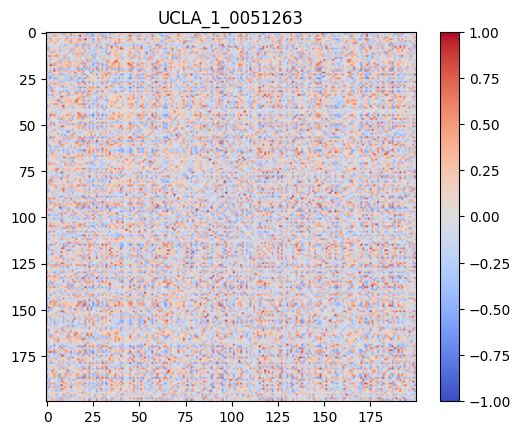

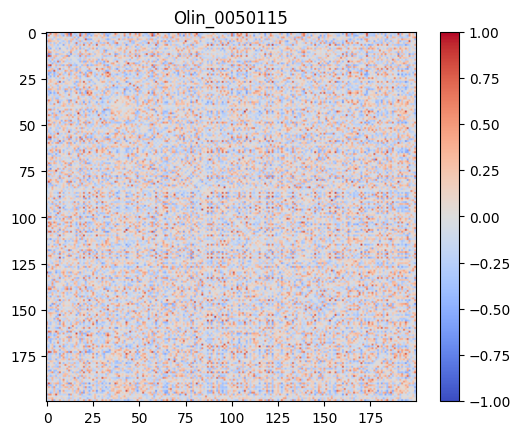

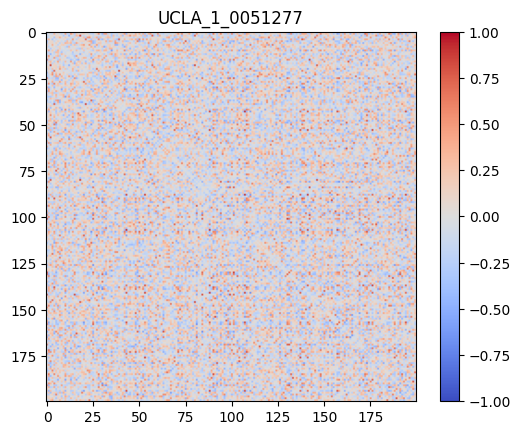

In [ ]:
# Visualize sample connectivity matrices
import matplotlib.pyplot as plt

sample_paths = list(fc_dir.glob("*.npy"))[:3]
for p in sample_paths:
    mat = np.load(p)
    plt.figure(figsize=(6, 6))
    plt.imshow(mat, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(label="Pearson correlation")
    plt.title(f"Connectivity matrix: {p.stem}")
    plt.show()

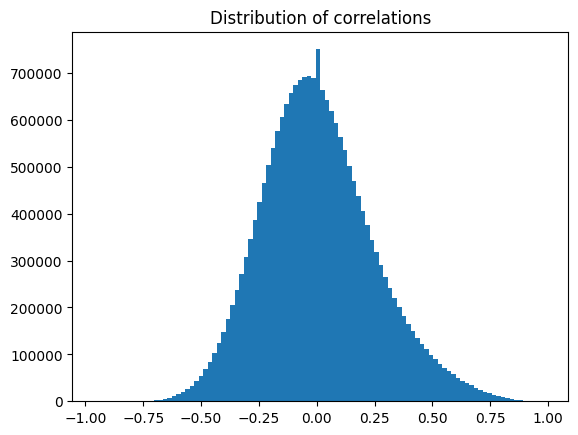

In [ ]:
# Histogram of correlation values across all subjects
all_vals = []
for p in fc_dir.glob("*.npy"):
    mat = np.load(p)
    vals = mat[np.triu_indices_from(mat, k=1)]  # Upper triangle only to avoid redundancy
    all_vals.extend(vals)

all_vals = np.array(all_vals)
plt.figure(figsize=(10, 4))
plt.hist(all_vals, bins=100, alpha=0.7, edgecolor='k')
plt.xlabel("Pearson correlation")
plt.ylabel("Frequency")
plt.title("Distribution of correlation values across all subjects")
plt.show()

/var/folders/d6/qn8gssfj7355xpg0c9755v400000gn/T/ipykernel_64261/979343762.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([means[labels==1], means[labels==2]], labels=["ASD", "Control"])


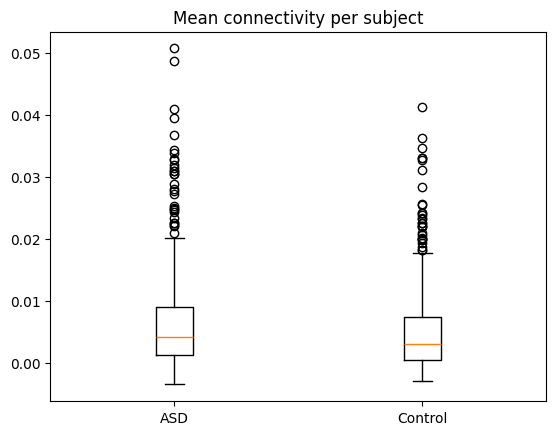

In [ ]:
# Box plot: Mean correlation strength by diagnostic group
df = pd.read_csv(index_path)

means = []
labels = []
for _, row in df.iterrows():
    fid = row["FILE_ID"]
    mat = np.load(fc_dir / f"{fid}.npy")
    vals = mat[np.triu_indices_from(mat, k=1)]
    means.append(vals.mean())
    labels.append(row["DX_GROUP"])

means = np.array(means)
labels = np.array(labels)

plt.figure(figsize=(8, 5))
plt.boxplot([means[labels==1], means[labels==2]], labels=["ASD", "Control"])
plt.ylabel("Mean correlation")
plt.title("Mean connectivity strength by diagnostic group")
plt.grid(axis='y', alpha=0.3)
plt.show()

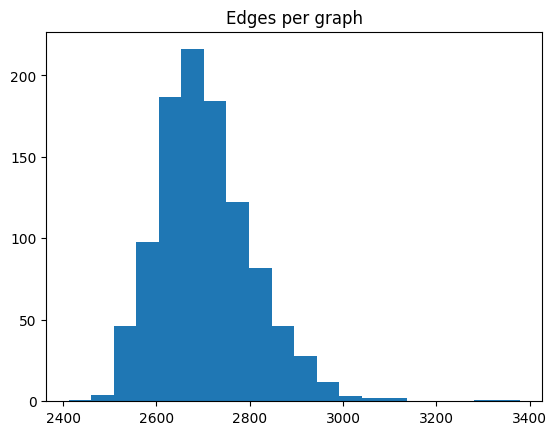

In [ ]:
# Histogram of edge counts across all graphs
edge_counts = [g.edge_index.shape[1] for g in graphs]
plt.figure(figsize=(8, 5))
plt.hist(edge_counts, bins=20, alpha=0.7, edgecolor='k')
plt.xlabel("Number of edges")
plt.ylabel("Frequency")
plt.title("Edge count distribution across graphs (top-10 per node)")
plt.grid(axis='y', alpha=0.3)
plt.show()

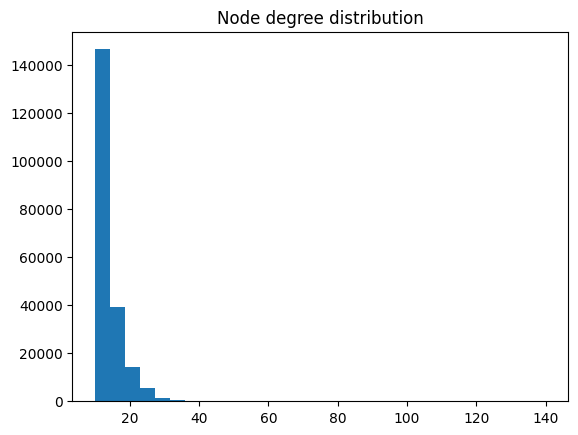

In [ ]:
# Histogram of node degrees across graphs
degrees = []
for g in graphs:
    deg = torch.bincount(g.edge_index[0])
    degrees.extend(deg.numpy())

plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=30, alpha=0.7, edgecolor='k')
plt.xlabel("Node degree")
plt.ylabel("Frequency")
plt.title("Node degree distribution across all graphs")
plt.grid(axis='y', alpha=0.3)
plt.show()

# Splitting the Data

In [ ]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
import torch

base = Path("data/abide_fmri")
mat_dir = base / "connectivity_matrices"
graph_path = base / "pyg" / "graphs_top10.pt"
index_path = base / "connectivity_index.csv"

# Step 1: Load subject labels
idx = pd.read_csv(index_path)[["FILE_ID", "DX_GROUP"]].drop_duplicates().copy()

# Step 2: Keep only subjects that actually have matrix files (enforce consistency)
matrix_ids = {p.stem for p in mat_dir.glob("*.npy")}
idx = idx[idx["FILE_ID"].isin(matrix_ids)].reset_index(drop=True)

# Step 3: Stratified 80/20 split preserving class balance at subject level
train_ids, test_ids = train_test_split(
    idx["FILE_ID"],
    test_size=0.2,
    random_state=42,
    stratify=idx["DX_GROUP"]
)
train_ids = set(train_ids)
test_ids = set(test_ids)

split_df = idx.copy()
split_df["split"] = split_df["FILE_ID"].map(lambda s: "train" if s in train_ids else "test")

# Step 4: Save split manifest as single source of truth
split_df.to_csv(base / "subject_split.csv", index=False)
split_df[split_df["split"] == "train"].to_csv(base / "train_subjects.csv", index=False)
split_df[split_df["split"] == "test"].to_csv(base / "test_subjects.csv", index=False)

print("Total:", len(split_df))
print(split_df["split"].value_counts())
print("\nClass counts by split:")
print(pd.crosstab(split_df["split"], split_df["DX_GROUP"]))

# Step 5: Split graphs using graph metadata IDs to ensure consistency between representations
if not graph_path.exists():
    raise FileNotFoundError(
        f"Missing {graph_path}. Re-run the graph-construction cell first to recreate graphs_top10.pt."
    )

# PyTorch >=2.6 defaults to weights_only=True, which cannot unpickle PyG Data objects.
graphs = torch.load(graph_path, weights_only=False)
graph_by_id = {}
missing_id_count = 0

for g in graphs:
    gid = getattr(g, "file_id", None)
    if gid is None:
        gid = getattr(g, "fid", None)
    if gid is None:
        missing_id_count += 1
        continue
    graph_by_id[str(gid)] = g

train_graphs = [graph_by_id[fid] for fid in sorted(train_ids) if fid in graph_by_id]
test_graphs = [graph_by_id[fid] for fid in sorted(test_ids) if fid in graph_by_id]

missing_train = len(train_ids) - len(train_graphs)
missing_test = len(test_ids) - len(test_graphs)

torch.save(train_graphs, base / "pyg" / "graphs_top10_train.pt")
torch.save(test_graphs, base / "pyg" / "graphs_top10_test.pt")

print("\nSaved graph splits:", len(train_graphs), "train,", len(test_graphs), "test")
if missing_id_count:
    print(f"Warning: {missing_id_count} graphs had no file_id/fid metadata and were skipped.")
if missing_train or missing_test:
    print(f"Warning: Missing graph IDs for split subjects -> train: {missing_train}, test: {missing_test}")

Total: 1035
split
train    828
test     207
Name: count, dtype: int64

Class counts by split:
DX_GROUP    1    2
split             
test      101  106
train     404  424

Saved graph splits: 828 train, 207 test


# Model Selection

## Baseline: Predicting the Majority Class

## Models Trained on the Matrix Representation

### Logistic Regression 

### Multilayer Perceptron (MLP) 

## Models Trained on the Graph Representation

### Graph Convolutional Network (GCN)  

#### Mathematical Basis of GCNs

## Graph Attention Network (GAT)

### Mathematical Basis of GATs

# Training with Cross-Validation and Hyperparameter Tuning

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
 )

# Shared modeling constants (used by matrix + graph pipelines)
RANDOM_SEED = 42
CV_FOLDS = 5
GRAPH_BATCH_SIZE = 32
GRAPH_EPOCHS = 40
GAT_DEFAULT_WEIGHT_DECAY = 1e-4
CLASS_NAMES = ["Control", "ASD"]

BASE_DIR = Path("data/abide_fmri")
MAT_DIR = BASE_DIR / "connectivity_matrices"
PYG_DIR = BASE_DIR / "pyg"

# Single CV object reused by all models
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

def load_and_flatten_matrices(file_ids):
    """Load connectivity matrices and flatten upper triangle into feature vectors."""
    X = []
    for fid in file_ids:
        mat_path = MAT_DIR / f"{fid}.npy"
        if mat_path.exists():
            mat = np.load(mat_path)
            features = mat[np.triu_indices_from(mat, k=1)]  # Extract upper triangle (19,900 dims)
            X.append(features)
    return np.array(X) if X else None

# Get train and test split IDs and labels
train_fids = split_df[split_df["split"] == "train"]["FILE_ID"].values
test_fids = split_df[split_df["split"] == "test"]["FILE_ID"].values

train_labels = split_df[split_df["split"] == "train"]["DX_GROUP"].values
test_labels = split_df[split_df["split"] == "test"]["DX_GROUP"].values

# Convert labels: 1=ASD -> 1, 2=Control -> 0
y_train = np.array([1 if l == 1 else 0 for l in train_labels])
y_test = np.array([1 if l == 1 else 0 for l in test_labels])

# Load connectivity matrices and flatten
X_matrix_train = load_and_flatten_matrices(train_fids)
X_matrix_test = load_and_flatten_matrices(test_fids)

# Z-score normalization using training set statistics
scaler = StandardScaler()
X_matrix_train = scaler.fit_transform(X_matrix_train)
X_matrix_test = scaler.transform(X_matrix_test)

print(f"Train shape: {X_matrix_train.shape}, Test shape: {X_matrix_test.shape}")
print(f"Class distribution (train): ASD={np.sum(y_train)}, Control={np.sum(y_train == 0)}")
print(f"Class distribution (test):  ASD={np.sum(y_test)}, Control={np.sum(y_test == 0)}")

Train shape: (828, 19900), Test shape: (207, 19900)
Class distribution (train): ASD=404, Control=424
Class distribution (test):  ASD=101, Control=106


In [ ]:
from sklearn.linear_model import LogisticRegression

# Hyperparameter grid for L2-regularized logistic regression
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10],  # Inverse regularization strength
    "penalty": ["l2"],
    "solver": ["lbfgs"],
    "class_weight": [None, "balanced"]  # Address class imbalance
}

# Grid search with ROC-AUC scoring
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    param_grid,
    cv=cv,
    n_jobs=-1,
    scoring="roc_auc"
)

print("Training Logistic Regression with hyperparameter tuning...")
grid.fit(X_matrix_train, y_train)

print(f"\nBest parameters: {grid.best_params_}")
print(f"Best CV ROC-AUC: {grid.best_score_:.4f}")

# Evaluate best model on held-out test set
y_pred = grid.predict(X_matrix_test)
y_pred_proba = grid.predict_proba(X_matrix_test)[:, 1]
test_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nTest ROC-AUC: {test_auc:.4f}")
print("\nTest set classification report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

Training Logistic Regression with hyperparameter tuning...

Best parameters: {'C': 0.001, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV score (ROC-AUC): 0.7677

Test ROC-AUC: 0.7264

Test set classification report:
              precision    recall  f1-score   support

     Control       0.66      0.74      0.70       106
         ASD       0.69      0.60      0.64       101

    accuracy                           0.67       207
   macro avg       0.67      0.67      0.67       207
weighted avg       0.67      0.67      0.67       207



In [ ]:
from sklearn.neural_network import MLPClassifier

# Minimal parameter grid for proof-of-concept (expand later for full tuning)
param_grid_mlp = {
    "hidden_layer_sizes": [(64,), (128, 64)],  # Single and two-layer configs
    "activation": ["relu"],
    "learning_rate_init": [0.001],
    "alpha": [0.001],  # L2 regularization
    "batch_size": [32]
}

# Grid search with ROC-AUC scoring
grid_mlp = GridSearchCV(
    MLPClassifier(max_iter=300, random_state=RANDOM_SEED, early_stopping=True, validation_fraction=0.1),
    param_grid_mlp,
    cv=cv,
    n_jobs=-1,
    scoring="roc_auc"
)

print("Training MLP with hyperparameter tuning (POC)...")
grid_mlp.fit(X_matrix_train, y_train)

print(f"\nBest parameters: {grid_mlp.best_params_}")
print(f"Best CV ROC-AUC: {grid_mlp.best_score_:.4f}")

# Evaluate best model on held-out test set
y_pred_mlp = grid_mlp.predict(X_matrix_test)
y_pred_proba_mlp = grid_mlp.predict_proba(X_matrix_test)[:, 1]
test_auc_mlp = roc_auc_score(y_test, y_pred_proba_mlp)

print(f"\nTest ROC-AUC: {test_auc_mlp:.4f}")
print("\nTest set classification report:")
print(classification_report(y_test, y_pred_mlp, target_names=CLASS_NAMES))

Training MLP with hyperparameter tuning (POC)...

Best parameters: {'activation': 'relu', 'alpha': 0.001, 'batch_size': 32, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001}
Best CV score (ROC-AUC): 0.7361

Test ROC-AUC: 0.6982

Test set classification report:
              precision    recall  f1-score   support

     Control       0.63      0.67      0.65       106
         ASD       0.63      0.59      0.61       101

    accuracy                           0.63       207
   macro avg       0.63      0.63      0.63       207
weighted avg       0.63      0.63      0.63       207



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool

# Reuse in-memory graph splits; fallback to disk if needed
if "train_graphs" not in globals() or "test_graphs" not in globals():
    train_graphs = torch.load(PYG_DIR / "graphs_top10_train.pt", weights_only=False)
    test_graphs = torch.load(PYG_DIR / "graphs_top10_test.pt", weights_only=False)

# Filter to only labeled graphs (exclude any with y=None)
train_graphs = [g for g in train_graphs if hasattr(g, "y") and g.y is not None]
test_graphs = [g for g in test_graphs if hasattr(g, "y") and g.y is not None]

if len(train_graphs) == 0 or len(test_graphs) == 0:
    raise ValueError("Train/test graph lists are empty after filtering labeled graphs.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Train graphs: {len(train_graphs)} | Test graphs: {len(test_graphs)}")

in_channels = train_graphs[0].x.shape[1]
num_classes = 2

# Keep graph CV folds aligned with shared CV configuration.
graph_cv_splits = int(cv.n_splits)
print(f"Graph CV folds: {graph_cv_splits}")

def make_loaders(train_data, test_data, batch_size=GRAPH_BATCH_SIZE):
    """Create DataLoaders for graph batching during training/evaluation."""
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

@torch.no_grad()
def predict_labels_and_probs(model, loader):
    """Return y_true, y_prob, y_pred arrays from a graph loader."""
    model.eval()
    ys, probs = [], []

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)
        p = torch.softmax(logits, dim=1)[:, 1]
        y = batch.y.view(-1).long()

        ys.extend(y.cpu().numpy().tolist())
        probs.extend(p.cpu().numpy().tolist())

    ys = np.array(ys)
    probs = np.array(probs)
    preds = (probs >= 0.5).astype(int)
    return ys, probs, preds

@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model on a graph loader; returns accuracy and ROC-AUC."""
    ys, probs, preds = predict_labels_and_probs(model, loader)
    acc = accuracy_score(ys, preds)
    auc = roc_auc_score(ys, probs) if len(np.unique(ys)) > 1 else np.nan
    return {"acc": acc, "auc": auc}

def train_for_epochs(model, train_loader, lr, weight_decay, epochs=GRAPH_EPOCHS):
    """Train one model for a fixed number of epochs on the provided loader."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            logits = model(batch)
            y = batch.y.view(-1).long()
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    return model

def train_one_model(model, train_loader, test_loader, lr, weight_decay, epochs=GRAPH_EPOCHS):
    """Train on train_loader then return metrics on test_loader."""
    model = train_for_epochs(model, train_loader, lr=lr, weight_decay=weight_decay, epochs=epochs)
    return evaluate(model, test_loader)

def cross_validate_graph_model(
    model_builder,
    graphs,
    lr,
    weight_decay,
    epochs=GRAPH_EPOCHS,
    batch_size=GRAPH_BATCH_SIZE,
    n_splits=CV_FOLDS,
    random_state=RANDOM_SEED,
 ):
    """Run stratified K-fold CV on training graphs and return aggregate metrics."""
    labels = np.array([int(g.y.view(-1).item()) for g in graphs])
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    fold_metrics = []
    for fold_idx, (tr_idx, va_idx) in enumerate(splitter.split(np.zeros(len(graphs)), labels), start=1):
        fold_train = [graphs[i] for i in tr_idx]
        fold_val = [graphs[i] for i in va_idx]

        fold_train_loader = DataLoader(fold_train, batch_size=batch_size, shuffle=True)
        fold_val_loader = DataLoader(fold_val, batch_size=batch_size, shuffle=False)

        model = model_builder()
        model = train_for_epochs(model, fold_train_loader, lr=lr, weight_decay=weight_decay, epochs=epochs)
        metrics = evaluate(model, fold_val_loader)
        fold_metrics.append(metrics)
        print(f"  Fold {fold_idx}/{n_splits} - acc: {metrics['acc']:.4f}, auc: {metrics['auc']:.4f}")

    accs = np.array([m["acc"] for m in fold_metrics], dtype=float)
    aucs = np.array([m["auc"] for m in fold_metrics], dtype=float)

    return {
        "cv_acc_mean": float(np.nanmean(accs)),
        "cv_acc_std": float(np.nanstd(accs)),
        "cv_auc_mean": float(np.nanmean(aucs)),
        "cv_auc_std": float(np.nanstd(aucs)),
        "fold_metrics": fold_metrics,
    }

class GCNNet(nn.Module):
    """Graph Convolutional Network: 2-layer GCN with dropout and global pooling."""
    def __init__(self, in_channels, hidden_dim=32, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.dropout = dropout
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)

class GATNet(nn.Module):
    """Graph Attention Network: 2-layer GAT with multi-head attention and global pooling."""
    def __init__(self, in_channels, hidden_dim=32, heads=2, dropout=0.5):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_dim, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, concat=True, dropout=dropout)
        self.dropout = dropout
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.elu(x)
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)

# Keep holdout loaders for final one-time test evaluation cell.
train_loader, test_loader = make_loaders(train_graphs, test_graphs, batch_size=GRAPH_BATCH_SIZE)
print("Graph setup ready: CV utilities + holdout loaders + model classes defined.")

Device: cpu
Train graphs: 828 | Test graphs: 207
Graph CV folds: 5
Graph setup ready: CV utilities + holdout loaders + model classes defined.


In [ ]:
# GCN hyperparameter sweep selected by stratified CV on training graphs.
gcn_configs = [
    (32, 0.5, 1e-3, 0),      # (hidden_dim, dropout, lr, weight_decay)
    (32, 0.5, 5e-4, 1e-4),
    (64, 0.5, 1e-3, 1e-4),
    (16, 0.2, 1e-3, 0),
]

gcn_results = []
print("\nGCN hyperparameter sweep (CV on training graphs):")
for hidden_dim, dropout, lr, weight_decay in gcn_configs:
    print(f"\nConfig: hidden_dim={hidden_dim}, dropout={dropout}, lr={lr}, weight_decay={weight_decay}")

    metrics = cross_validate_graph_model(
        model_builder=lambda: GCNNet(in_channels=in_channels, hidden_dim=hidden_dim, dropout=dropout),
        graphs=train_graphs,
        lr=lr,
        weight_decay=weight_decay,
        epochs=GRAPH_EPOCHS,
        batch_size=GRAPH_BATCH_SIZE,
        n_splits=graph_cv_splits,
        random_state=RANDOM_SEED,
    )

    row = {
        "hidden_dim": hidden_dim,
        "dropout": dropout,
        "lr": lr,
        "weight_decay": weight_decay,
        "cv_acc_mean": metrics["cv_acc_mean"],
        "cv_acc_std": metrics["cv_acc_std"],
        "cv_auc_mean": metrics["cv_auc_mean"],
        "cv_auc_std": metrics["cv_auc_std"],
    }
    gcn_results.append(row)
    print(row)

gcn_results = sorted(
    gcn_results,
    key=lambda x: (np.nan_to_num(x["cv_auc_mean"], nan=-1), x["cv_acc_mean"]),
    reverse=True,
)
print("\nBest GCN config by CV:", gcn_results[0])


GCN hyperparameter sweep (CV on training graphs):

Config: hidden_dim=32, dropout=0.5, lr=0.001, weight_decay=0
  Fold 1/5 - acc: 0.6867, auc: 0.7656
  Fold 2/5 - acc: 0.6386, auc: 0.6871
  Fold 3/5 - acc: 0.5663, auc: 0.6478
  Fold 4/5 - acc: 0.6424, auc: 0.7024
  Fold 5/5 - acc: 0.6364, auc: 0.6822
{'hidden_dim': 32, 'dropout': 0.5, 'lr': 0.001, 'weight_decay': 0, 'cv_acc_mean': 0.634070828769624, 'cv_acc_std': 0.03864592409849497, 'cv_auc_mean': 0.6970190372445274, 'cv_auc_std': 0.038651998153764425}

Config: hidden_dim=32, dropout=0.5, lr=0.0005, weight_decay=0.0001
  Fold 1/5 - acc: 0.6747, auc: 0.7662
  Fold 2/5 - acc: 0.6446, auc: 0.7320
  Fold 3/5 - acc: 0.5783, auc: 0.6463
  Fold 4/5 - acc: 0.6303, auc: 0.6942
  Fold 5/5 - acc: 0.6424, auc: 0.7006
{'hidden_dim': 32, 'dropout': 0.5, 'lr': 0.0005, 'weight_decay': 0.0001, 'cv_acc_mean': 0.6340635268346112, 'cv_acc_std': 0.03147672695059187, 'cv_auc_mean': 0.7078511602171733, 'cv_auc_std': 0.04002285522756177}

Config: hidden_dim

In [ ]:
# GAT hyperparameter sweep selected by stratified CV on training graphs.
gat_configs = [
    (32, 2, 0.5, 1e-3),      # (hidden_dim, heads, dropout, lr)
    (32, 4, 0.5, 5e-4),
    (16, 2, 0.2, 1e-3),
    (16, 4, 0.5, 1e-3),
]

gat_results = []
print("\nGAT hyperparameter sweep (CV on training graphs):")
for hidden_dim, heads, dropout, lr in gat_configs:
    print(f"\nConfig: hidden_dim={hidden_dim}, heads={heads}, dropout={dropout}, lr={lr}")

    metrics = cross_validate_graph_model(
        model_builder=lambda: GATNet(in_channels=in_channels, hidden_dim=hidden_dim, heads=heads, dropout=dropout),
        graphs=train_graphs,
        lr=lr,
        weight_decay=GAT_DEFAULT_WEIGHT_DECAY,
        epochs=GRAPH_EPOCHS,
        batch_size=GRAPH_BATCH_SIZE,
        n_splits=graph_cv_splits,
        random_state=RANDOM_SEED,
    )

    row = {
        "hidden_dim": hidden_dim,
        "heads": heads,
        "dropout": dropout,
        "lr": lr,
        "weight_decay": GAT_DEFAULT_WEIGHT_DECAY,
        "cv_acc_mean": metrics["cv_acc_mean"],
        "cv_acc_std": metrics["cv_acc_std"],
        "cv_auc_mean": metrics["cv_auc_mean"],
        "cv_auc_std": metrics["cv_auc_std"],
    }
    gat_results.append(row)
    print(row)

gat_results = sorted(
    gat_results,
    key=lambda x: (np.nan_to_num(x["cv_auc_mean"], nan=-1), x["cv_acc_mean"]),
    reverse=True,
)
print("\nBest GAT config by CV:", gat_results[0])


GAT sweep
{'hidden_dim': 32, 'heads': 2, 'dropout': 0.5, 'lr': 0.001, 'weight_decay': 0.0001, 'acc': 0.5700483091787439, 'auc': 0.6643937978703531}
{'hidden_dim': 32, 'heads': 4, 'dropout': 0.5, 'lr': 0.0005, 'weight_decay': 0.0001, 'acc': 0.5314009661835749, 'auc': 0.6441247898374742}
{'hidden_dim': 16, 'heads': 2, 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 0.0001, 'acc': 0.5942028985507246, 'auc': 0.6183448533532598}
{'hidden_dim': 16, 'heads': 4, 'dropout': 0.5, 'lr': 0.001, 'weight_decay': 0.0001, 'acc': 0.6086956521739131, 'auc': 0.637072669531104}

Best GAT config: {'hidden_dim': 32, 'heads': 2, 'dropout': 0.5, 'lr': 0.001, 'weight_decay': 0.0001, 'acc': 0.5700483091787439, 'auc': 0.6643937978703531}


# Evaluation on the Test Set

In [ ]:
# Matrix-model evaluations (already tuned via GridSearchCV)
y_pred_logreg = grid.predict(X_matrix_test)
y_pred_proba_logreg = grid.predict_proba(X_matrix_test)[:, 1]
acc_logreg = accuracy_score(y_test, y_pred_logreg)
auc_logreg = roc_auc_score(y_test, y_pred_proba_logreg)
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

y_pred_mlp = grid_mlp.predict(X_matrix_test)
y_pred_proba_mlp = grid_mlp.predict_proba(X_matrix_test)[:, 1]
acc_mlp = accuracy_score(y_test, y_pred_mlp)
auc_mlp = roc_auc_score(y_test, y_pred_proba_mlp)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

def evaluate_graph_model_on_test(model_builder, cfg, epochs=GRAPH_EPOCHS):
    """Train on graph train split once, then evaluate on graph test split."""
    model = model_builder()
    model = train_for_epochs(
        model,
        train_loader,
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"],
        epochs=epochs,
    )
    y_true, y_prob, y_pred = predict_labels_and_probs(model, test_loader)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    cm = confusion_matrix(y_true, y_pred)
    return acc, auc, cm, y_true, y_prob, y_pred

def print_eval_line(model_name, acc, auc):
    print(f"{model_name}: Accuracy={acc:.4f} | ROC-AUC={auc:.4f}")

# Graph-model evaluations (best config selected by CV)
best_gcn = gcn_results[0]
acc_gcn, auc_gcn, cm_gcn, y_test_gcn, y_pred_gcn_probs, y_pred_gcn = evaluate_graph_model_on_test(
    model_builder=lambda: GCNNet(
        in_channels=in_channels,
        hidden_dim=best_gcn["hidden_dim"],
        dropout=best_gcn["dropout"],
    ),
    cfg=best_gcn,
    epochs=GRAPH_EPOCHS,
 )

best_gat = gat_results[0]
acc_gat, auc_gat, cm_gat, y_test_gat, y_pred_gat_probs, y_pred_gat = evaluate_graph_model_on_test(
    model_builder=lambda: GATNet(
        in_channels=in_channels,
        hidden_dim=best_gat["hidden_dim"],
        heads=best_gat["heads"],
        dropout=best_gat["dropout"],
    ),
    cfg=best_gat,
    epochs=GRAPH_EPOCHS,
 )

# Concise summary for all models
print_eval_line("Logistic Regression", acc_logreg, auc_logreg)
print_eval_line("MLP", acc_mlp, auc_mlp)
print_eval_line("GCN", acc_gcn, auc_gcn)
print_eval_line("GAT", acc_gat, auc_gat)

# Keep table artifact for downstream comparison plots
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "MLP", "GCN", "GAT"],
    "Accuracy": [acc_logreg, acc_mlp, acc_gcn, acc_gat],
    "ROC-AUC": [auc_logreg, auc_mlp, auc_gcn, auc_gat],
})

Logistic Regression - Test Set
  Accuracy: 0.6715 | ROC-AUC: 0.7264
MLP - Test Set
  Accuracy: 0.6329 | ROC-AUC: 0.6982
GCN - Test Set
  Accuracy: 0.6425 | ROC-AUC: 0.6812
GAT - Test Set
  Accuracy: 0.6280 | ROC-AUC: 0.6656


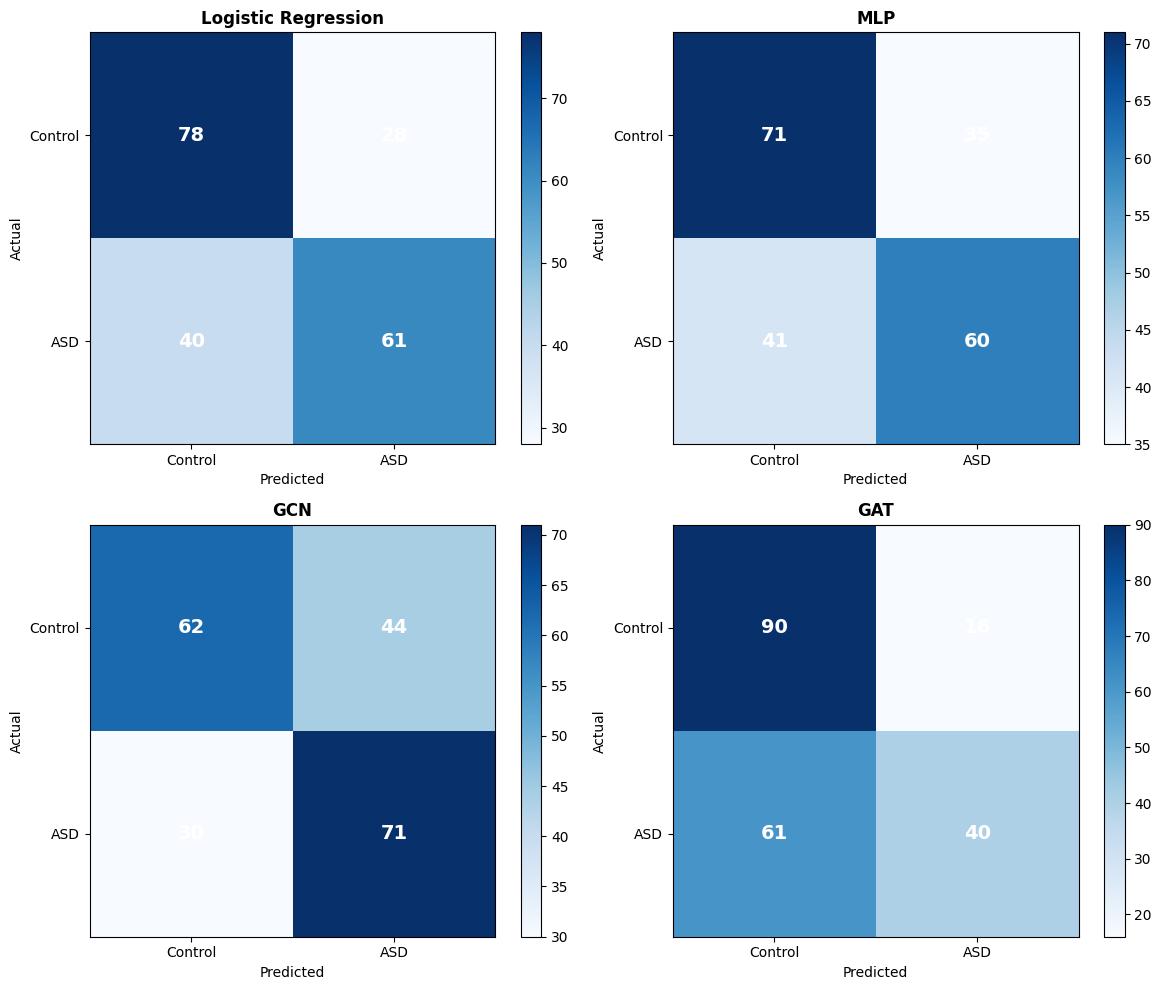

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models = ["Logistic Regression", "MLP", "GCN", "GAT"]
cms = [cm_logreg, cm_mlp, cm_gcn, cm_gat]
axes = axes.flatten()

for model_name, cm, ax in zip(models, cms, axes):
    im = ax.imshow(cm, cmap="Blues", aspect="auto")
    ax.set_title(model_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(CLASS_NAMES)
    ax.set_yticklabels(CLASS_NAMES)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="white", fontsize=14, fontweight="bold")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

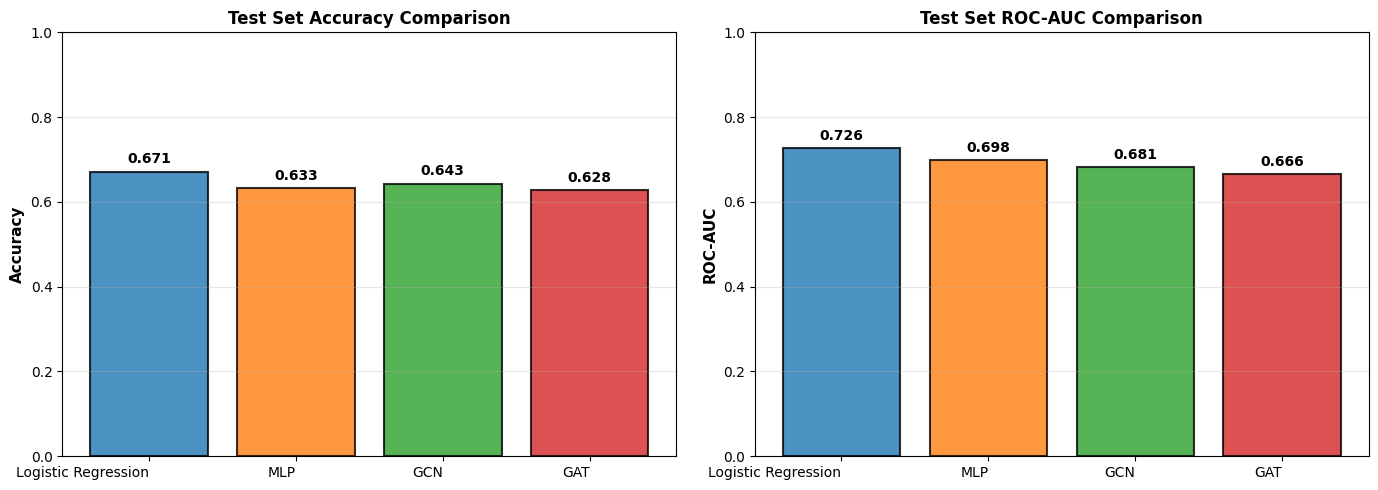

Best Accuracy: Logistic Regression (0.6715)
Best ROC-AUC:  Logistic Regression (0.7264)


In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
x_pos = np.arange(len(results_df))

ax1.bar(x_pos, results_df["Accuracy"], color=colors, alpha=0.8, edgecolor="black", linewidth=1.5)
ax1.set_ylabel("Accuracy", fontsize=11, fontweight="bold")
ax1.set_title("Test Set Accuracy Comparison", fontsize=12, fontweight="bold")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(results_df["Model"], ha="right")
ax1.set_ylim([0, 1])
ax1.grid(axis="y", alpha=0.3)
for i, v in enumerate(results_df["Accuracy"]):
    ax1.text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

ax2.bar(x_pos, results_df["ROC-AUC"], color=colors, alpha=0.8, edgecolor="black", linewidth=1.5)
ax2.set_ylabel("ROC-AUC", fontsize=11, fontweight="bold")
ax2.set_title("Test Set ROC-AUC Comparison", fontsize=12, fontweight="bold")
ax2.set_xticks(x_pos)
ax2.set_xticklabels(results_df["Model"], ha="right")
ax2.set_ylim([0, 1])
ax2.grid(axis="y", alpha=0.3)
for i, v in enumerate(results_df["ROC-AUC"]):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

# Summary
best_acc_idx = results_df["Accuracy"].idxmax()
best_auc_idx = results_df["ROC-AUC"].idxmax()
print(f"Best Accuracy: {results_df.loc[best_acc_idx, 'Model']} ({results_df.loc[best_acc_idx, 'Accuracy']:.4f})")
print(f"Best ROC-AUC:  {results_df.loc[best_auc_idx, 'Model']} ({results_df.loc[best_auc_idx, 'ROC-AUC']:.4f})")

# Results and Conclusions 

# Limitations 

# Executive Summary

# AI Statement

# References